In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv('mymoviedb(1).csv', lineterminator='\n')

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [2]:
df.info()
df.describe(include='all')
df['Genre'].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [3]:
df.duplicated().sum()
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [4]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Date'] = df['Release_Date'].dt.year

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [5]:
df.drop(columns=['Overview', 'Original_Language', 'Poster_Url'], inplace=True, errors='ignore')

df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre'], dtype='object')

In [6]:
def categorize_col(dataframe, col, labels):
    edges = [
        dataframe[col].describe()['min'],
        dataframe[col].describe()['25%'],
        dataframe[col].describe()['50%'],
        dataframe[col].describe()['75%'],
        dataframe[col].describe()['max']
    ]

    dataframe[col + '_Category'] = pd.cut(
        dataframe[col],
        bins=edges,
        labels=labels,
        include_lowest=True,
        duplicates='drop'
    )
    return dataframe

In [7]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

df = categorize_col(df, 'Vote_Average', labels)

In [8]:
df['Vote_Average_Category'].value_counts()

not_popular    2567
popular        2450
average        2412
below_avg      2398
Name: Vote_Average_Category, dtype: int64

In [9]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date             0
Title                    0
Popularity               0
Vote_Count               0
Vote_Average             0
Genre                    0
Vote_Average_Category    0
dtype: int64

In [10]:
movies_df = df.copy()

In [11]:
genre_df = movies_df.copy()

genre_df['Genre'] = genre_df['Genre'].str.split(', ')
genre_df = genre_df.explode('Genre').reset_index(drop=True)

genre_df['Genre'] = genre_df['Genre'].astype('category')

genre_df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


In [12]:
sns.set_style('whitegrid')

In [13]:
genre_df['Genre'].value_counts().idxmax()

'Drama'

In [14]:
movies_df.loc[movies_df['Vote_Average'].idxmax(), ['Title', 'Vote_Average']]

Title           Kung Fu Master Huo Yuanjia
Vote_Average                          10.0
Name: 9391, dtype: object

In [15]:
movies_df.loc[movies_df['Popularity'].idxmax(), ['Title', 'Popularity']]

Title         Spider-Man: No Way Home
Popularity                   5083.954
Name: 0, dtype: object

In [16]:
movies_df.loc[movies_df['Popularity'].idxmin(), ['Title', 'Popularity']]

Title         The United States vs. Billie Holiday
Popularity                                  13.354
Name: 9825, dtype: object

In [17]:
movies_df['Release_Date'].value_counts().idxmax()

2021

In [18]:
top_10_genres = genre_df['Genre'].value_counts().head(10)
top_10_genres

Drama        3744
Comedy       3031
Action       2686
Thriller     2488
Adventure    1853
Romance      1476
Horror       1470
Animation    1439
Family       1414
Fantasy      1308
Name: Genre, dtype: int64

In [19]:
movies_df.sort_values(by='Popularity', ascending=False).head(10)[['Title', 'Popularity']]

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [20]:
movies_df.sort_values(by='Vote_Average', ascending=False).head(10)[['Title', 'Vote_Average']]

,Title,Vote_Average
9391,Kung Fu Master Huo Yuanjia,10.0
7339,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2325,Impossible Things,9.1
7401,My Sex Doll,9.0
7014,Sex School: Dorms of Desire,9.0
6728,Mission «Sky»,9.0
2391,The Three Deaths of Marisela Escobedo,9.0
7039,Bring the Soul: The Movie,8.9
5069,"Ni tuyo, Ni mía",8.9


In [21]:
genre_df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False)

Genre
Adventure          53.742888
Fantasy            53.081342
Animation          52.433848
Action             50.890133
Science Fiction    49.511334
Family             46.610616
Crime              44.747295
Thriller           42.946258
Mystery            40.093590
Horror             38.264498
Comedy             37.873669
Western            36.187912
War                35.298075
Music              33.771410
Romance            30.866030
Drama              30.077651
TV Movie           29.954715
Documentary        29.235377
History            28.395827
Name: Popularity, dtype: float64

In [22]:
genre_df.groupby('Genre')['Vote_Average'].mean().sort_values(ascending=False)

Genre
History            6.965574
War                6.948701
Music              6.879322
Animation          6.846560
Western            6.754745
Drama              6.706143
Documentary        6.663721
Family             6.581047
Romance            6.560772
Crime              6.552013
Fantasy            6.526300
Adventure          6.456719
TV Movie           6.438318
Mystery            6.434282
Comedy             6.382976
Action             6.330268
Science Fiction    6.257423
Thriller           6.246141
Horror             5.940068
Name: Vote_Average, dtype: float64

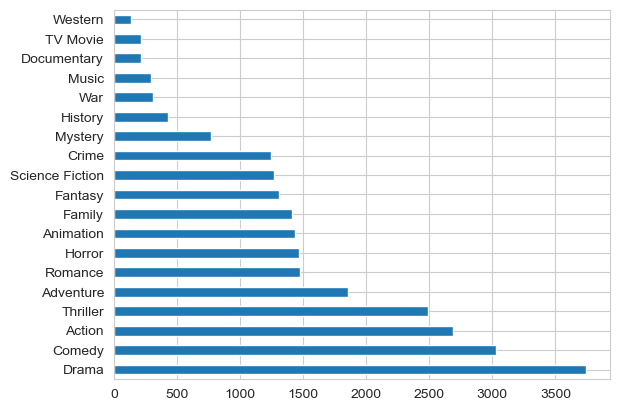

In [23]:
genre_df['Genre'].value_counts().plot(kind='barh')
plt.show()

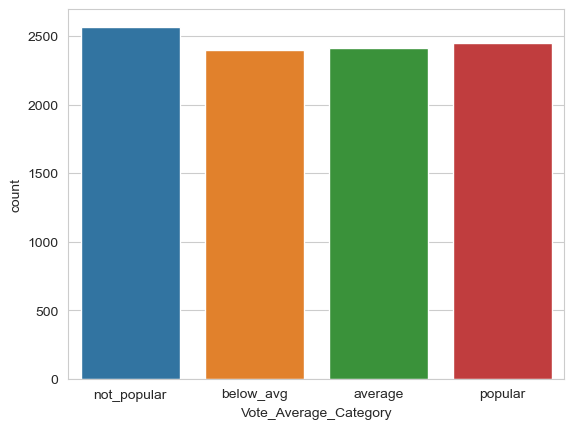

In [24]:
sns.countplot(data=movies_df, x='Vote_Average_Category')
plt.show()

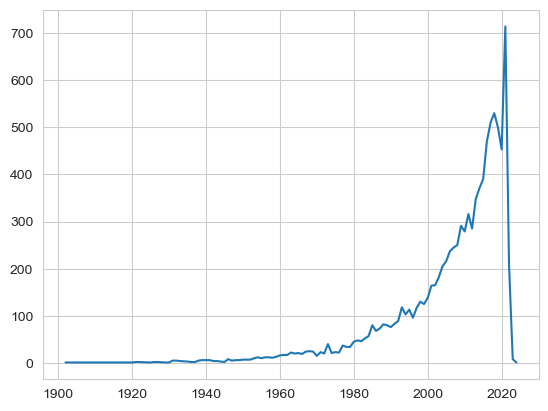

In [25]:
movies_df['Release_Date'].value_counts().sort_index().plot()
plt.show()

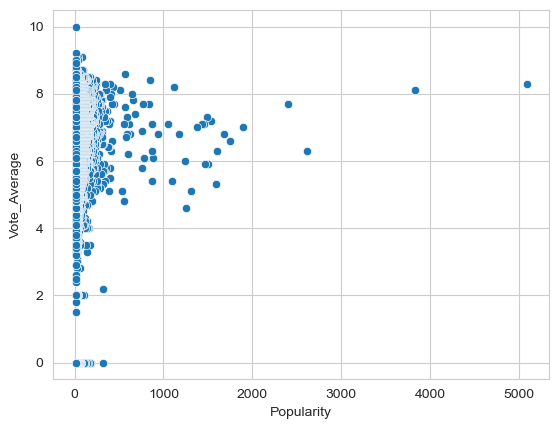

In [26]:
sns.scatterplot(data=movies_df, x='Popularity', y='Vote_Average')
plt.show()

In [27]:
print("Most frequent genre:", genre_df['Genre'].value_counts().idxmax())
print("Top movie rating:", movies_df.loc[movies_df['Vote_Average'].idxmax(), 'Title'])
print("Top popularity movie:", movies_df.loc[movies_df['Popularity'].idxmax(), 'Title'])
print("Best year:", movies_df['Release_Date'].value_counts().idxmax())

Most frequent genre: Drama
Top movie rating: Kung Fu Master Huo Yuanjia
Top popularity movie: Spider-Man: No Way Home
Best year: 2021


In [28]:
movies_df['Popularity'].describe()

count    9827.000000
mean       40.326088
std       108.873998
min        13.354000
25%        16.128500
50%        21.199000
75%        35.191500
max      5083.954000
Name: Popularity, dtype: float64

In [29]:
def create_popularity_category(df):
    bins = [
        df['Popularity'].min(),
        df['Popularity'].quantile(0.33),
        df['Popularity'].quantile(0.66),
        df['Popularity'].max()
    ]
    
    labels = ['Low', 'Medium', 'High']
    
    df['Popularity_Category'] = pd.cut(
        df['Popularity'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    
    return df

movies_df = create_popularity_category(movies_df)

In [30]:
movies_df['Popularity_Category'].value_counts()

High      3341
Low       3243
Medium    3243
Name: Popularity_Category, dtype: int64

In [31]:
movies_df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre', 'Vote_Average_Category', 'Popularity_Category'], dtype='object')

In [32]:
# ML dataset
ml_df = movies_df[['Genre', 'Vote_Average', 'Vote_Count', 'Release_Date', 'Popularity_Category']].copy()

# safety cleanup
ml_df = ml_df.dropna()

ml_df.head()

,Genre,Vote_Average,Vote_Count,Release_Date,Popularity_Category
0,"Action, Adventure, Science Fiction",8.3,8940,2021,High
1,"Crime, Mystery, Thriller",8.1,1151,2022,High
2,Thriller,6.3,122,2022,High
3,"Animation, Comedy, Family, Fantasy",7.7,5076,2021,High
4,"Action, Adventure, Thriller, War",7.0,1793,2021,High


In [33]:
X = ml_df[['Genre', 'Vote_Average', 'Vote_Count', 'Release_Date']]
y = ml_df['Popularity_Category']

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (9827, 4)
y shape: (9827,)
High      3341
Low       3243
Medium    3243
Name: Popularity_Category, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7861, 4)
Test shape: (1966, 4)


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ['Genre']
numerical_features = ['Vote_Average', 'Vote_Count', 'Release_Date']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

cv_scores = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.5139
Random Forest: 0.5415
Gradient Boosting: 0.5432


In [37]:
best_model_name = max(cv_scores, key=cv_scores.get)
print("Best model:", best_model_name)

best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

final_pipeline.fit(X_train, y_train)

Best model: Gradient Boosting


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genre']),
                                                 ('num', StandardScaler(),
                                                  ['Vote_Average', 'Vote_Count',
                                                   'Release_Date'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = final_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5534079348931842

Classification Report:

              precision    recall  f1-score   support

        High       0.69      0.61      0.65       668
         Low       0.51      0.68      0.58       649
      Medium       0.47      0.37      0.42       649

    accuracy                           0.55      1966
   macro avg       0.56      0.55      0.55      1966
weighted avg       0.56      0.55      0.55      1966



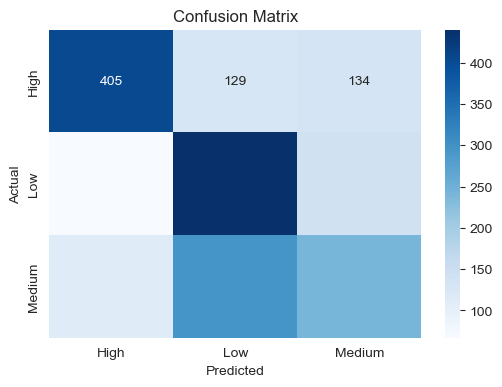

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred, labels=final_pipeline.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_pipeline.classes_,
            yticklabels=final_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred

results.head(10)

,Genre,Vote_Average,Vote_Count,Release_Date,Actual,Predicted
7059,"Drama, Family",7.5,302,2015,Low,Medium
2816,"Drama, Music, Romance",7.3,456,2021,High,High
4614,Thriller,4.8,1804,2015,Medium,High
3629,"Action, Comedy, War",6.5,1433,1993,Medium,Medium
8554,"Adventure, Comedy, Romance",6.1,142,1963,Low,Low
656,"Drama, Comedy",8.3,14406,2011,High,High
8993,"Animation, Family",6.1,37,2005,Low,Low
64,"Action, Thriller",6.4,175,2021,High,High
4132,Drama,6.9,109,2016,Medium,Low
9822,"Drama, Crime",7.6,896,1973,Low,Medium


In [41]:
sample_movie = pd.DataFrame({
    'Genre': ['Action, Adventure, Science Fiction'],
    'Vote_Average': [7.8],
    'Vote_Count': [1200],
    'Release_Date': [2022]
})

prediction = final_pipeline.predict(sample_movie)
print("Predicted Popularity Category:", prediction[0])

Predicted Popularity Category: High


In [42]:
import joblib

joblib.dump(final_pipeline, 'movie_popularity_pipeline.pkl')
print("Model saved as movie_popularity_pipeline.pkl")

Model saved as movie_popularity_pipeline.pkl


In [43]:
print("Training Accuracy:", final_pipeline.score(X_train, y_train))
print("Testing Accuracy:", final_pipeline.score(X_test, y_test))

Training Accuracy: 0.5892380104312428
Testing Accuracy: 0.5534079348931842
